## Stage 1: Setup
Importing the libraries used throughout this project — Pandas/NumPy for data handling, Scikit-learn for modeling, Matplotlib/Seaborn for visualization.

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## Stage 2: Load Dataset
Loading the Medical Transcriptions dataset directly from GitHub (CC0 Public Domain, sourced from mtsamples.com).

In [2]:
# Load dataset from GitHub
url = 'https://raw.githubusercontent.com/lambdadesrushti/medtriage-nlp/refs/heads/main/mtsamples.csv'
df = pd.read_csv(url)

print(df.shape)
print(df.columns)
df.head()

(4999, 6)
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## Stage 3: Explore the Data
Checking the raw `medical_specialty` categories and how many cases each has, before deciding which ones qualify as real hospital departments.

In [3]:
# Inspect specialty distribution
pd.set_option('display.max_rows', 100)
print(df['medical_specialty'].value_counts())

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

## Stage 4: Clean Data & Map to Departments
Filtering out non-department categories (e.g., "Office Notes," "Consult") and mapping the remaining specialties to 11 standard hospital departments. Keywords are cleaned to remove any direct mention of department names, preventing label leakage.

In [4]:
# Clean data and map to departments
department_map = {
    'Cardiovascular / Pulmonary': 'Cardiology','Orthopedic': 'Orthopedics',
    'Gastroenterology': 'Gastroenterology','Neurology': 'Neurology',
    'Obstetrics / Gynecology': 'Gynecology','Urology': 'Urology',
    'ENT - Otolaryngology': 'ENT','Ophthalmology': 'Ophthalmology',
    'Nephrology': 'Nephrology','Pediatrics - Neonatal': 'Pediatrics',
    'Psychiatry / Psychology': 'Psychiatry',
}

df_clean = df[df['medical_specialty'].str.strip().isin(department_map.keys())].copy()
df_clean['department'] = df_clean['medical_specialty'].str.strip().map(department_map)
df_clean = df_clean.dropna(subset=['description'])
df_clean['description'] = df_clean['description'].astype(str)
df_clean['keywords'] = df_clean['keywords'].fillna('')

# Remove any keyword phrase that mentions a department/specialty name (prevents label leakage)
specialty_terms = set()
for v in department_map.keys():
    specialty_terms.update(v.lower().replace('/', ' ').split())
for v in department_map.values():
    specialty_terms.update(v.lower().split())

def clean_keywords(kw):
    parts = [p.strip() for p in kw.split(',')]
    cleaned = [p for p in parts if not any(term in p.lower() for term in specialty_terms)]
    return ' '.join(cleaned)

df_clean['keywords_clean'] = df_clean['keywords'].apply(clean_keywords)
df_clean['clinical_text'] = df_clean['description'] + ' ' + df_clean['keywords_clean']

print(df_clean['department'].value_counts())
print("\nTotal rows after cleaning:", df_clean.shape[0])

department
Cardiology          372
Orthopedics         355
Gastroenterology    230
Neurology           223
Gynecology          160
Urology             158
ENT                  98
Ophthalmology        83
Nephrology           81
Pediatrics           70
Psychiatry           53
Name: count, dtype: int64

Total rows after cleaning: 1883


## Stage 5: Minimum Sample-Size Filter
A safety check to ensure every department has enough samples for a reliable train/test split.

In [5]:
# threshold check
counts = df_clean['department'].value_counts()
valid_depts = counts[counts >= 40].index
df_clean = df_clean[df_clean['department'].isin(valid_depts)]

print(df_clean['department'].value_counts())

department
Cardiology          372
Orthopedics         355
Gastroenterology    230
Neurology           223
Gynecology          160
Urology             158
ENT                  98
Ophthalmology        83
Nephrology           81
Pediatrics           70
Psychiatry           53
Name: count, dtype: int64


In [6]:
# Style setup
sns.set_theme(style='white', font_scale=1.05)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

PALETTE = ['#F94144','#F3722C','#F8961E','#F9C74F','#90BE6D','#43AA8B',
           '#4D908E','#577590','#277DA1','#9D4EDD','#F72585']

## Visual Check: Class Distribution
Before training, visualizing how many cases each department has — important context for interpreting later results given the class imbalance.

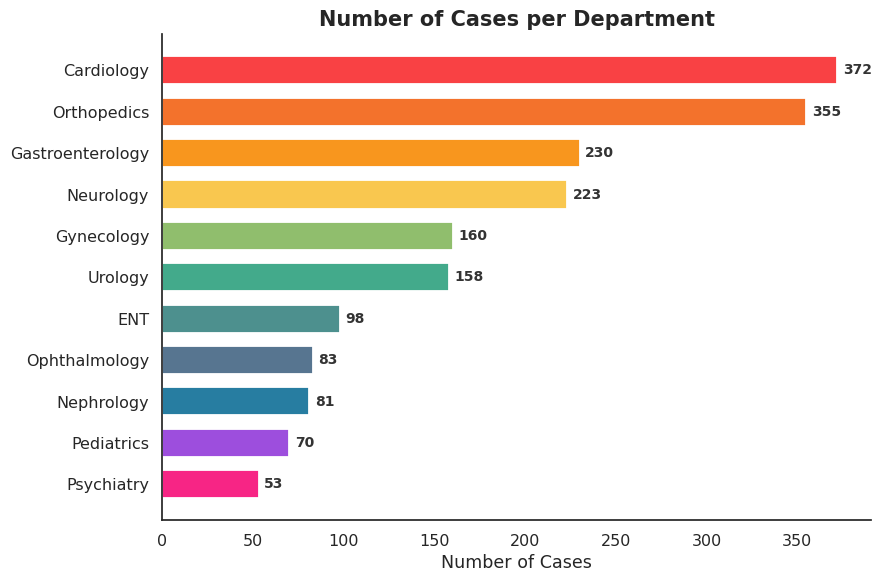

In [7]:
# Dataset distribution chart
plt.figure(figsize=(9,6))
order = df_clean['department'].value_counts().index
vals = df_clean['department'].value_counts()[order].values
bars = plt.barh(order, vals, color=PALETTE[:len(order)], edgecolor='white', linewidth=1.3, height=0.68)
for b, v in zip(bars, vals):
    plt.text(v+3, b.get_y()+b.get_height()/2, str(v), va='center', fontweight='bold', fontsize=10, color='#333')
plt.gca().invert_yaxis()
plt.title('Number of Cases per Department')
plt.xlabel('Number of Cases')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Stage 6: Train/Test Split
Splitting the data 80/20, stratified by department, so every department is fairly represented in both the training and test sets.

In [8]:
# Train/test split
X = df_clean['clinical_text']
y = df_clean['department']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Stage 7: Build the Model
Using TF-IDF (unigrams + bigrams) to convert text into numerical features, paired with a Logistic Regression classifier. Class-balanced weighting ensures smaller departments aren't ignored.

In [9]:
# Build and train the pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), stop_words='english',
                               sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(max_iter=3000, C=1, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## Stage 8: Evaluate Overall Performance
Checking accuracy and per-department precision/recall/F1 on the unseen test set.

In [10]:
# Evaluate overall performance
y_pred = pipeline.predict(X_test)

print("Overall Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Overall Accuracy: 0.843501326259947

Classification Report:

                  precision    recall  f1-score   support

      Cardiology       0.89      0.91      0.90        74
             ENT       0.84      0.80      0.82        20
Gastroenterology       0.93      0.83      0.87        46
      Gynecology       0.91      0.91      0.91        32
      Nephrology       0.72      0.81      0.76        16
       Neurology       0.67      0.71      0.69        45
   Ophthalmology       0.94      1.00      0.97        17
     Orthopedics       0.86      0.87      0.87        71
      Pediatrics       0.50      0.57      0.53        14
      Psychiatry       0.90      0.90      0.90        10
         Urology       0.96      0.84      0.90        32

        accuracy                           0.84       377
       macro avg       0.83      0.83      0.83       377
    weighted avg       0.85      0.84      0.85       377



In [11]:
# Audit: short vs. long descriptions
word_counts = X_test.apply(lambda x: len(x.split()))
median_len = word_counts.median()

short_mask = word_counts <= median_len
long_mask = word_counts > median_len

short_acc = accuracy_score(y_test[short_mask], y_pred[short_mask])
long_acc = accuracy_score(y_test[long_mask], y_pred[long_mask])

print(f"Median description length: {median_len} words")
print(f"Short descriptions - Accuracy: {short_acc:.3f}")
print(f"Long descriptions  - Accuracy: {long_acc:.3f}")

Median description length: 33.0 words
Short descriptions - Accuracy: 0.823
Long descriptions  - Accuracy: 0.866


## Stage 10: Explainability
Inspecting which words most strongly influence each department's prediction — making the model's decisions interpretable rather than a black box.

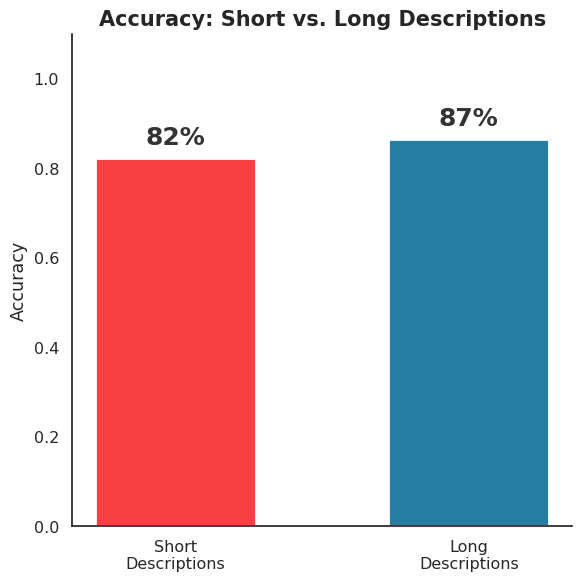

In [12]:
# Visualize the audit finding
plt.figure(figsize=(6,6))
bars = plt.bar(['Short\nDescriptions','Long\nDescriptions'], [short_acc, long_acc],
               color=['#F94144','#277DA1'], edgecolor='white', linewidth=2, width=0.55)
for b, val in zip(bars, [short_acc, long_acc]):
    plt.text(b.get_x()+b.get_width()/2, val+0.03, f'{val:.0%}', ha='center', fontsize=18, fontweight='bold', color='#333')
plt.ylabel('Accuracy'); plt.ylim(0,1.1)
plt.title('Accuracy: Short vs. Long Descriptions')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

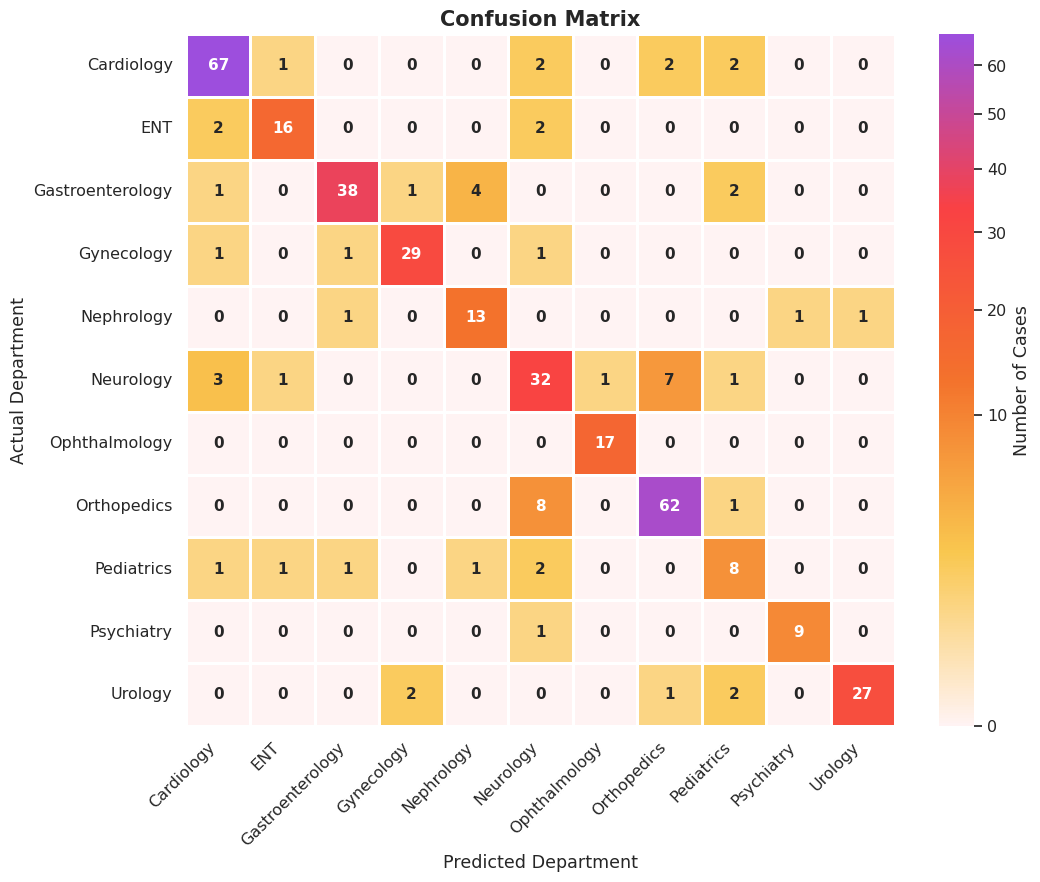

In [13]:
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
custom_cmap = mcolors.LinearSegmentedColormap.from_list('aesthetic', ['#FFF3F3','#F9C74F','#F3722C','#F94144','#9D4EDD'])
norm = mcolors.PowerNorm(gamma=0.42, vmin=0, vmax=cm.max())
plt.figure(figsize=(11,9))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, norm=norm,
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_,
            cbar_kws={'label':'Number of Cases'}, linewidths=1, linecolor='white',
            annot_kws={'fontsize':11,'fontweight':'bold'})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Department'); plt.ylabel('Actual Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

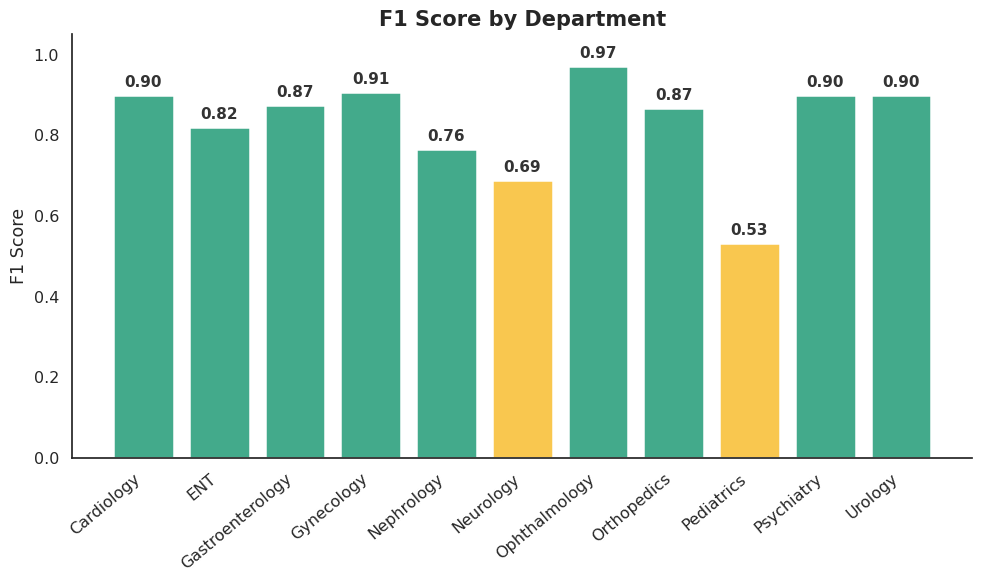

In [14]:
# F1 score per department, color-coded by strength
from sklearn.metrics import f1_score

f1s = f1_score(y_test, y_pred, average=None, labels=pipeline.classes_)
colors = ['#43AA8B' if f>=0.7 else '#F9C74F' if f>=0.5 else '#F94144' for f in f1s]
plt.figure(figsize=(10,6))
bars = plt.bar(pipeline.classes_, f1s, color=colors, edgecolor='white', linewidth=1.8)
for b, f in zip(bars, f1s):
    plt.text(b.get_x()+b.get_width()/2, f+0.02, f'{f:.2f}', ha='center', fontsize=11, fontweight='bold', color='#333')
plt.title('F1 Score by Department')
plt.ylabel('F1 Score'); plt.ylim(0,1.05)
plt.xticks(rotation=40, ha='right')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Stage 10: Explainability
Inspecting which words most strongly influence each department's prediction — making the model's decisions interpretable rather than a black box.

In [15]:
# Explainability: top words per department
feature_names = np.array(pipeline.named_steps['tfidf'].get_feature_names_out())
clf = pipeline.named_steps['clf']

for i, department in enumerate(clf.classes_):
    top10 = np.argsort(clf.coef_[i])[-10:]
    print(f"\nTop words for {department}:")
    print(feature_names[top10])


Top words for Cardiology:
['catheterization' 'breath' 'cardiac' 'heart' 'bronchoscopy' 'lung'
 'atrial' 'artery' 'coronary' 'chest']

Top words for ENT:
['media' 'otitis media' 'tonsillitis' 'hypertrophy' 'otitis'
 'adenotonsillitis' 'adenoidectomy' 'tonsillectomy' 'ear' 'nasal']

Top words for Gastroenterology:
['esophageal' 'appendectomy' 'laparoscopic cholecystectomy' 'esophagus'
 'esophagogastroduodenoscopy' 'cholecystectomy' 'abdominal' 'laparoscopic'
 'colon' 'colonoscopy']

Top words for Gynecology:
['tubal' 'delivery' 'intrauterine' 'uterus' 'fetal' 'hysterectomy'
 'pelvic' 'vaginal' 'breast' 'pregnancy']

Top words for Nephrology:
['ct' 'ct abdomen' 'vein' 'hemodialysis' 'failure' 'pelvis' 'fistula'
 'renal failure' 'kidney' 'renal']

Top words for Neurology:
['craniotomy' 'weakness' 'hematoma' 'temporal' 'headache' 'eeg' 'cerebral'
 'spine' 'mri' 'brain']

Top words for Ophthalmology:
['intraocular' 'lens' 'right eye' 'vision' 'blepharoplasty' 'scleral'
 'cataract' 'vitrecto

## Stage 11: Live Interactive Demo
A live demo using the actual trained model above — type a symptom description or click an example, and see the model's real-time top-3 predicted departments with confidence scores.

In [16]:
# LIVE Interactive Demo
!pip install ipywidgets --quiet
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

DEPT_COLORS = {
    'Cardiology': '#F94144', 'ENT': '#F3722C', 'Gastroenterology': '#F8961E',
    'Gynecology': '#D8A400', 'Nephrology': '#90BE6D', 'Neurology': '#43AA8B',
    'Ophthalmology': '#4D908E', 'Orthopedics': '#577590', 'Pediatrics': '#277DA1',
    'Psychiatry': '#9D4EDD', 'Urology': '#F72585',
}

EXAMPLES = {
    'Chest pain': 'sharp chest pain radiating to the left arm with shortness of breath',
    'Knee injury': 'severe joint pain and swelling in the right knee after a fall',
    'Eye irritation': 'blurry vision and redness in the left eye for three days',
    'Sinus issue': 'sinus congestion and nasal blockage with facial pressure',
    'Ear pain': 'ear pain and hearing loss for the past week',
    'Stomach ache': 'abdominal pain and nausea after eating',
}

text_input = widgets.Textarea(
    placeholder='Describe the symptoms...',
    layout=widgets.Layout(width='520px', height='80px')
)
predict_button = widgets.Button(description='🔍 Predict Department', button_style='',
    style={'button_color': '#FF6B5B'}, layout=widgets.Layout(width='200px', height='40px'))
predict_button.style.text_color = 'white'

chip_buttons = [widgets.Button(description=label, layout=widgets.Layout(width='auto', height='30px'))
                for label in EXAMPLES]
chip_row = widgets.HBox(chip_buttons)
output = widgets.Output()

def render_result_html(text):
    probs = pipeline.predict_proba([text])[0]
    ranked = sorted(zip(pipeline.classes_, probs), key=lambda x: -x[1])[:3]
    rows = ''
    for cls, p in ranked:
        color = DEPT_COLORS.get(cls, '#999')
        pct = p * 100
        rows += f'''
        <div style="display:flex;align-items:center;gap:12px;margin-bottom:10px;">
          <div style="width:150px;font-weight:600;font-size:14px;display:flex;align-items:center;gap:8px;">
            <span style="width:10px;height:10px;border-radius:50%;background:{color};display:inline-block;"></span>{cls}
          </div>
          <div style="flex:1;height:26px;background:#F0F5F3;border-radius:8px;overflow:hidden;">
            <div style="height:100%;width:{max(pct,3):.1f}%;background:{color};border-radius:8px;
                        display:flex;align-items:center;justify-content:flex-end;padding-right:8px;">
              <span style="color:white;font-size:12px;font-weight:700;">{pct:.1f}%</span>
            </div>
          </div>
        </div>'''
    note = ''
    if ranked[0][1] < 0.35:
        note = '''<div style="margin-top:10px;padding:10px 14px;background:#FFF2EA;color:#8A4A2B;
                   border-radius:8px;font-size:13px;">⚠ Low confidence — input may be outside our 11 trained
                   departments or lacks distinctive clinical vocabulary. This is expected behavior for a
                   closed-set classifier, not an error.</div>'''
    return f'<div style="font-family:Arial,sans-serif;padding:8px 0;">{rows}{note}</div>'

def on_predict(b):
    with output:
        clear_output()
        text = text_input.value.strip()
        if not text:
            print("Please enter a symptom description.")
            return
        display(HTML(render_result_html(text)))

def make_chip_handler(label):
    def handler(b):
        text_input.value = EXAMPLES[label]
        on_predict(b)
    return handler

for btn, label in zip(chip_buttons, EXAMPLES):
    btn.on_click(make_chip_handler(label))

predict_button.on_click(on_predict)

display(HTML('<h3 style="font-family:Arial;color:#0B4F4A;">🩺 MedTriage-NLP — Live Demo</h3>'))
display(widgets.HTML('<p style="color:#51665F;font-family:Arial;font-size:13px;">Click an example or type your own:</p>'))
display(chip_row)
display(text_input)
display(predict_button)
display(output)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.7 MB/s eta 0:00:00


HTML(value='<p style="color:#51665F;font-family:Arial;font-size:13px;">Click an example or type your own:</p>'…

Textarea(value='', layout=Layout(height='80px', width='520px'), placeholder='Describe the symptoms...')

Button(description='🔍 Predict Department', layout=Layout(height='40px', width='200px'), style=ButtonStyle(butt…

Output()